# Titanic Dataset Overview

The Titanic dataset contains information about passengers such as age, gender, ticket fare, passenger class, and survival status.

The objective of this exploratory data analysis (EDA) is to identify patterns, trends, and important factors that influenced passenger survival during the Titanic disaster.

In [31]:
#importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Loading the Titnaic dataset
df = pd.read_csv("train.csv")

In [33]:
#Displaying first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [34]:
# Checking rows and columns
df.shape

(891, 12)

In [35]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [36]:
# Checking missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Data Cleaning

Handling missing values is an important step in data analysis. In this project:

- Missing values in the Age column are filled using median values.
- Missing values in the Embarked column are filled using mode values.
- Cabin column is dropped because it contains too many missing values.

In [37]:
# Filling missing Age values with median
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_1728/24308790.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [38]:
# Filling missing Embarked values with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_1728/405293267.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [39]:
# Dropping Cabin column
df.drop('Cabin', axis=1, inplace=True)

# Survival Count Insights

1. The number of passengers who did not survive was higher.

2. Fewer passengers survived the disaster.

3. Survival distribution is imbalanced in the dataset.

4. The Titanic disaster caused heavy passenger loss.

5. Survival analysis is an important part of this dataset.

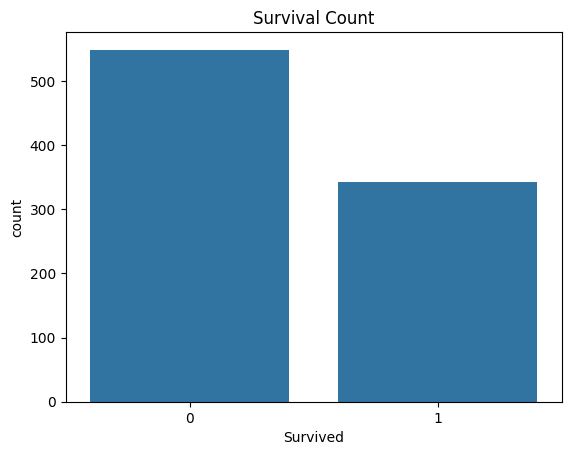

In [40]:
# Survival count graph
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

# Key Insights

1. Female passengers had higher survival rates than males.

2. First-class passengers survived more compared to lower classes.

3. Most passengers were between 20–40 years old.

4. Cabin column contained many missing values.

5. Higher fare passengers had better survival chances.


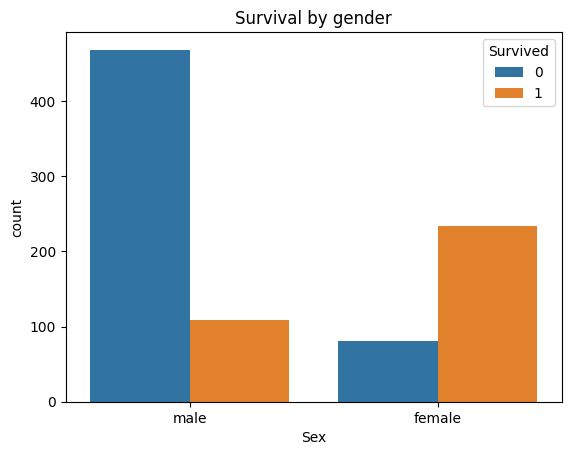

In [41]:
# Survival by gender
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by gender")
plt.show()

# Passenger Class Insights

1. First-class passengers had the highest survival rate.

2. Third-class passengers had the highest number of deaths.

3. Wealthier passengers were more likely to survive.

4. Passenger class had a strong impact on survival chances.

5. Lower-class passengers faced greater survival risk during the disaster.

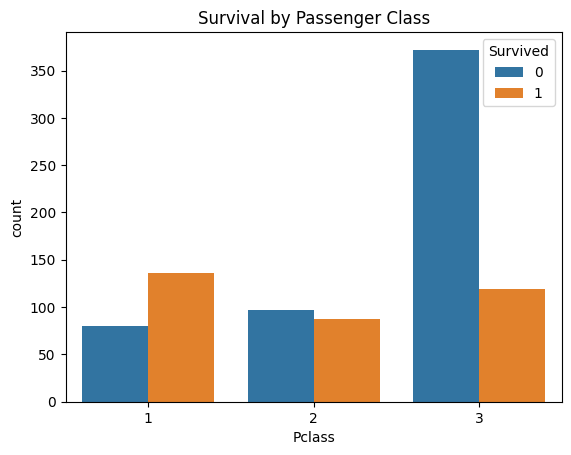

In [42]:
# Survival by Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

# Age Distribution Insights

1. Most passengers were between 20 and 40 years old.

2. There were fewer elderly passengers on the Titanic.

3. The age distribution was slightly right-skewed.

4. Some children were also present among the passengers.

5. Young adults formed the majority of the dataset.

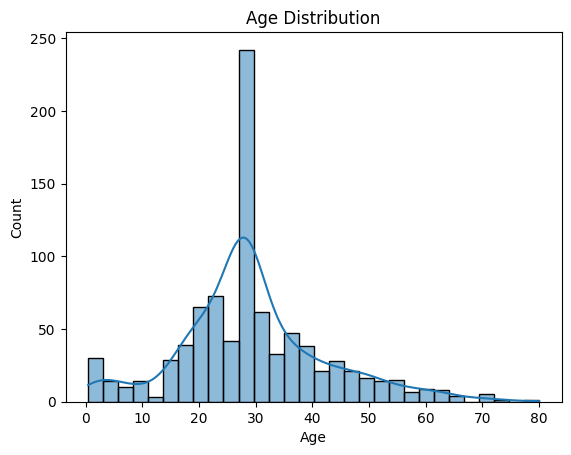

In [43]:
# Age distribution graph
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Fare Distribution Insights

1. Most passengers paid lower fares.

2. Only a small number of passengers paid very high fares.

3. The fare distribution is highly skewed.

4. Higher ticket fares were mostly associated with upper-class passengers.

5. Fare values show the economic differences among passengers.

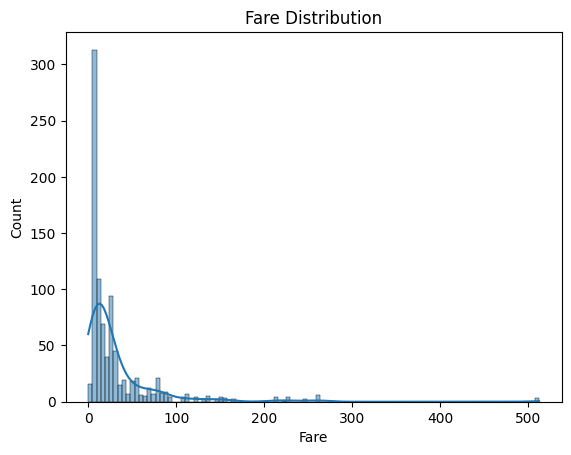

In [44]:
# Fare distribution graph
sns.histplot(df['Fare'], kde=True)
plt.title('Fare Distribution')
plt.show()

# Heatmap Insights

1. Passenger class and fare showed a strong relationship.

2. Survival had some correlation with fare and passenger class.

3. Age had a weaker correlation with survival.

4. Some numerical features were positively related.

5. Heatmaps help identify relationships between numerical variables.

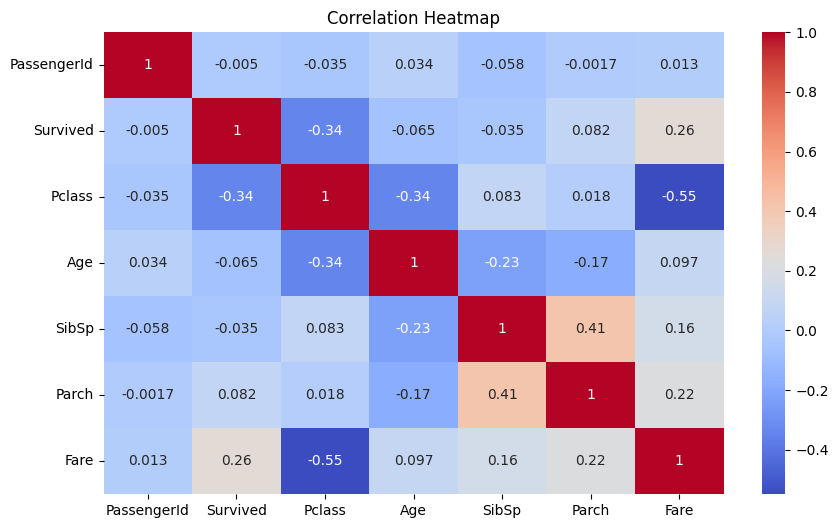

In [45]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Additional Insights

Female passengers across multiple age groups had better survival rates compared to male passengers.

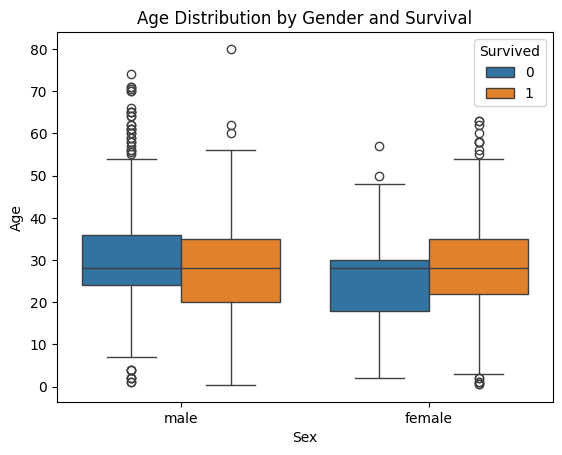

In [46]:
# Age distribution by gender and survival

sns.boxplot(x='Sex', y='Age', hue='Survived', data=df)
plt.title("Age Distribution by Gender and Survival")
plt.show()



# Libraries Used

- Pandas
- Matplotlib
- Seaborn

# Conclusion

This exploratory data analysis on the Titanic dataset identified important survival patterns among passengers.

Factors such as gender, passenger class, and fare significantly influenced survival chances. Data cleaning, visualization, and statistical analysis techniques were used to better understand the dataset and extract meaningful insights.